In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

In [2]:
df = pd.DataFrame(
    fetch_california_housing().data, columns=fetch_california_housing().feature_names
)
df["MedHouseVal"] = fetch_california_housing().target
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
for lr in [0.01, 0.05, 0.1, 1]:

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=lr,
        max_depth=10,
        random_state=42
    )

    model.fit(X_train, y_train)

    score = model.score(X_test,y_test)

    print(lr, score)

0.01 0.7799390557178212
0.05 0.8342957510645407
0.1 0.8338638340191721
0.1 0.8338638340191721
1 0.6819793109820651


In [8]:
model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=10,
        random_state=42
    )

model.fit(X_train, y_train)

score = model.score(X_test,y_test)
score

0.8338638340191721

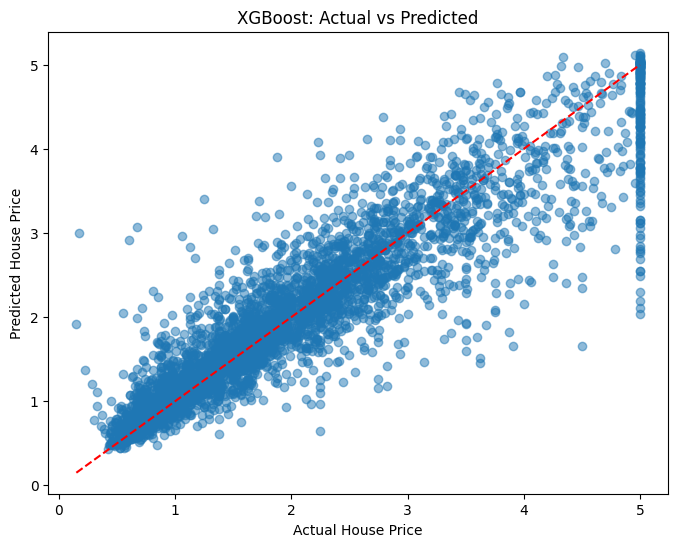

In [9]:
pred = model.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, pred, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("XGBoost: Actual vs Predicted")

plt.show()